# Introduction

Today we'll dive deep into a dataset all about LEGO. From the dataset we can ask whole bunch of interesting questions about the history of the LEGO company, their product offering, and which LEGO set ultimately rules them all:

<ul type="square">
<li>What is the most enormous LEGO set ever created and how many parts did it have?</li>

<li>How did the LEGO company start out? In which year were the first LEGO sets released and how many sets did the company sell when it first launched?</li>

<li>Which LEGO theme has the most sets? Is it one of LEGO's own themes like Ninjago or a theme they licensed liked Harry Potter or Marvel Superheroes?</li>

<li>When did the LEGO company really expand its product offering? Can we spot a change in the company strategy based on how many themes and sets did it released year-on-year?</li>

<li>Did LEGO sets grow in size and complexity over time? Do older LEGO 
sets tend to have more or fewer parts than newer sets?</li>
</ul>

**Data Source**

[Rebrickable](https://rebrickable.com/downloads/) has compiled data on all the LEGO pieces in existence. I recommend you use download the .csv files provided in this lesson. 

# Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Exploration

**Challenge**: How many different colours does the LEGO company produce? Read the colors.csv file in the data folder and find the total number of unique colours. Try using the [.nunique() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html?highlight=nunique#pandas.DataFrame.nunique) to accomplish this.

In [2]:
colors = pd.read_csv('/Volumes/Zweidrive/100DOC/Day 74 (Aggregate and Merge Data with Pandas)/LEGO Notebook and Data/data/colors.csv')

In [3]:
unique_colors = colors["name"].nunique()

In [4]:
print(f"There are {unique_colors} LEGO colors")

There are 135 LEGO colors


**Challenge**: Find the number of transparent colours where <code>is_trans == 't'</code> versus the number of opaque colours where <code>is_trans == 'f'</code>. See if you can accomplish this in two different ways.

In [5]:
transparent = colors[colors["is_trans"] == 't'].shape[0]
opaque = colors[colors["is_trans"] == 'f'].shape[0]
print(f"There are {transparent} transparent LEGO colors and {opaque} opaque LEGO colors.")

There are 28 transparent LEGO colors and 107 opaque LEGO colors.


In [6]:
transparency_counts = colors["is_trans"].value_counts()
transparent = transparency_counts["t"]
opaque = transparency_counts["f"]
print(f"There are {transparent} transparent LEGO colors and {opaque} opaque LEGO colors.")

There are 28 transparent LEGO colors and 107 opaque LEGO colors.


<h3>Understanding LEGO Themes vs. LEGO Sets</h3>

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

<img src="https://i.imgur.com/aKcwkSx.png">

A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

<img src="https://i.imgur.com/whB1olq.png">

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

**Challenge**: Read the sets.csv data and take a look at the first and last couple of rows. 

In [7]:
sets = pd.read_csv('/Volumes/Zweidrive/100DOC/Day 74 (Aggregate and Merge Data with Pandas)/LEGO Notebook and Data/data/sets.csv')

In [8]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [9]:
sets.tail()

,set_num,name,year,theme_id,num_parts
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


**Challenge**: In which year were the first LEGO sets released and what were these sets called?

In [10]:
first_year = sets["year"].min()
first_sets = sets[sets["year"] == first_year]["name"].to_list()
print(f"The first LEGO sets were released in {first_year}.")
print(f"The first LEGO sets to be released were the follwing sets:\n")
print("\n".join(first_sets))

The first LEGO sets were released in 1949.
The first LEGO sets to be released were the follwing sets:

Extra-Large Gift Set (ABB)
Large Gift Set (ABB)
Medium Gift Set (ABB)
Small Brick Set (ABB)
Small Doors and Windows Set (ABB)


**Challenge**: How many different sets did LEGO sell in their first year? How many types of LEGO products were on offer in the year the company started?

In [11]:
product_types = sets[sets["year"] == first_year]["theme_id"].nunique()
print(f"In its first year, LEGO sold {len(first_sets)} different sets.")
print(f"The company had {product_types} types of LEGO products on offer in the year the company started.")

In its first year, LEGO sold 5 different sets.
The company had 2 types of LEGO products on offer in the year the company started.


**Challenge**: Find the top 5 LEGO sets with the most number of parts. 

In [12]:
top_5 = sets.sort_values("num_parts", ascending=False).head()
set_names = top_5["name"].to_list()
part_counts = top_5["num_parts"].to_list()
print("The top 5 LEGO sets with the most number of parts was as follows:\n")
for name, parts in zip(set_names, part_counts):
    print(f"{name} with {parts} parts")

The top 5 LEGO sets with the most number of parts was as follows:

The Ultimate Battle for Chima with 9987 parts
UCS Millennium Falcon with 7541 parts
Hogwarts Castle with 6020 parts
Taj Mahal with 5923 parts
Taj Mahal with 5922 parts


**Challenge**: Use <code>.groupby()</code> and <code>.count()</code> to show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019? 

In [13]:
sets_yoy = sets.groupby("year").size()
sets_yoy_df = sets.groupby("year").count()
print(sets_yoy_df)
sets_1955 = sets_yoy.loc[1955]
sets_2019 = sets_yoy.loc[2019]
diff = sets_2019 - sets_1955
print(f"There were {diff} more sets released in 2019 than in 1955.")

      set_num  name  theme_id  num_parts
year                                    
1949        5     5         5          5
1950        6     6         6          6
1953        4     4         4          4
1954       14    14        14         14
1955       28    28        28         28
...       ...   ...       ...        ...
2017      786   786       786        786
2018      816   816       816        816
2019      840   840       840        840
2020      674   674       674        674
2021        3     3         3          3

[71 rows x 4 columns]
There were 812 more sets released in 2019 than in 1955.


**Challenge**: Show the number of LEGO releases on a line chart using Matplotlib. <br>
<br>
Note that the .csv file is from late 2020, so to plot the full calendar years, you will have to exclude some data from your chart. Can you use the slicing techniques covered in Day 21 to avoid plotting the last two years? The same syntax will work on Pandas DataFrames. 

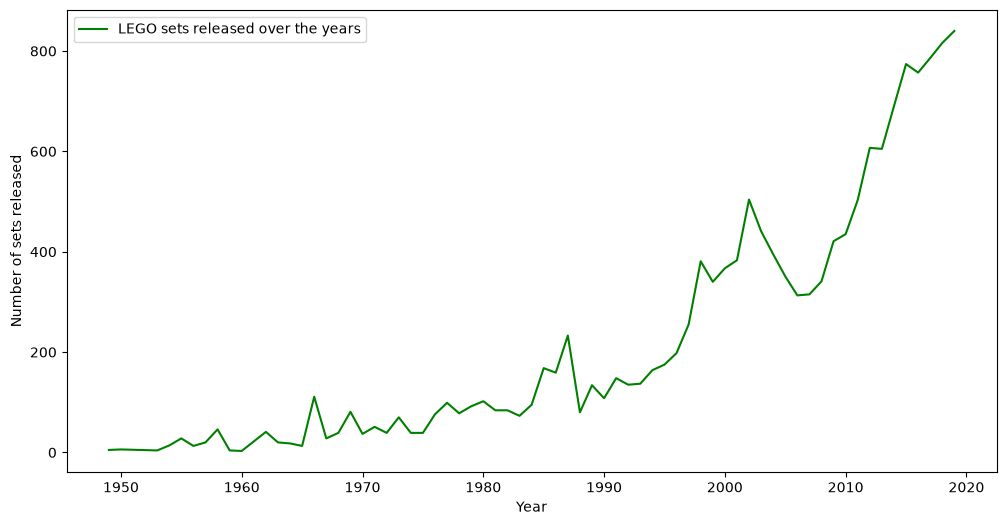

In [14]:
plt.figure(figsize=(12,6))
plt.xlabel("Year")
plt.ylabel("Number of sets released")
plt.plot(sets_yoy_df.index[:-2], sets_yoy_df.set_num[:-2], label="LEGO sets released over the years", color="green")
plt.legend()
plt.show()

### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

In [27]:
unique_themes = sets.groupby("year")["theme_id"].nunique()
print("The number of different themes shipped by year were as follows:\n")
for year, themes in unique_themes.items():
    if themes == 1:
        print(f"{themes} theme in {year}")
    else:
        print(f"{themes} themes in {year}")

The number of different themes shipped by year were as follows:

2 themes in 1949
1 theme in 1950
2 themes in 1953
2 themes in 1954
4 themes in 1955
3 themes in 1956
4 themes in 1957
3 themes in 1958
3 themes in 1959
3 themes in 1960
6 themes in 1961
4 themes in 1962
8 themes in 1963
9 themes in 1964
8 themes in 1965
13 themes in 1966
12 themes in 1967
16 themes in 1968
18 themes in 1969
18 themes in 1970
14 themes in 1971
13 themes in 1972
17 themes in 1973
14 themes in 1974
15 themes in 1975
26 themes in 1976
22 themes in 1977
25 themes in 1978
20 themes in 1979
32 themes in 1980
26 themes in 1981
24 themes in 1982
29 themes in 1983
30 themes in 1984
45 themes in 1985
44 themes in 1986
36 themes in 1987
37 themes in 1988
37 themes in 1989
39 themes in 1990
46 themes in 1991
45 themes in 1992
45 themes in 1993
50 themes in 1994
55 themes in 1995
60 themes in 1996
62 themes in 1997
85 themes in 1998
80 themes in 1999
65 themes in 2000
71 themes in 2001
72 themes in 2002
80 themes in 20

**Challenge**: Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021). 

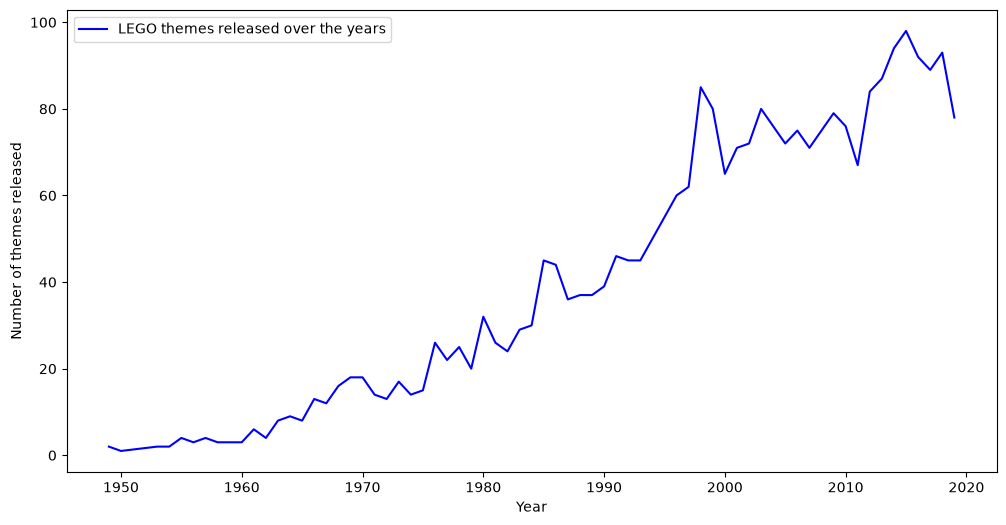

In [29]:
plt.figure(figsize=(12, 6))

plt.xlabel("Year")
plt.ylabel("Number of themes released")

plt.plot(
    unique_themes.index[:-2],
    unique_themes.values[:-2], #type:ignore
    label="LEGO themes released over the years",
    color="blue"
)

plt.legend()
plt.show()

### Line Charts with Two Seperate Axes

**Challenge**: Use the <code>.groupby()</code> and <code>.agg()</code> function together to figure out the average number of parts per set. How many parts did the average LEGO set released in 1954 compared to say, 2017?

In [37]:
parts_per_set=round(sets.groupby('year').agg({'num_parts': pd.Series.mean}))

In [38]:
print(parts_per_set)

      num_parts
year           
1949      100.0
1950        1.0
1953       14.0
1954       12.0
1955       37.0
...         ...
2017      222.0
2018      214.0
2019      208.0
2020      260.0
2021        0.0

[71 rows x 1 columns]


### Scatter Plots in Matplotlib

**Challenge**: Has the size and complexity of LEGO sets increased over time based on the number of parts? Plot the average number of parts over time using a Matplotlib scatter plot. See if you can use the [scatter plot documentation](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.scatter.html) before I show you the solution. Do you spot a trend in the chart? 

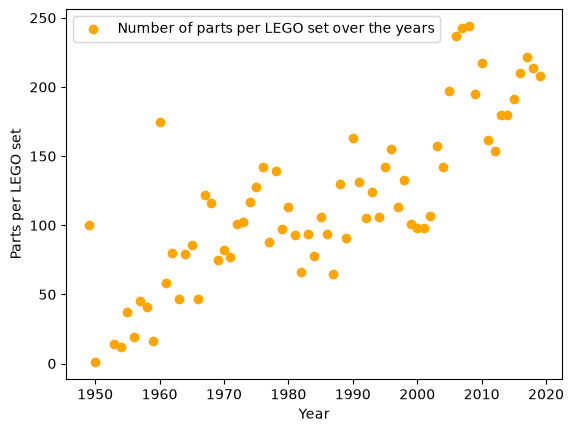

In [39]:
plt.xlabel("Year")
plt.ylabel("Parts per LEGO set")
plt.scatter(parts_per_set.index[:-2], parts_per_set.num_parts[:-2], label="Number of parts per LEGO set over the years", color="orange")
plt.legend()
plt.show()

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets? 

In [53]:
themes = pd.read_csv('/Volumes/Zweidrive/100DOC/Day 74 (Aggregate and Merge Data with Pandas)/LEGO Notebook and Data/data/themes.csv')
set_theme_count=sets["theme_id"].value_counts()
most_common_theme_id = set_theme_count[:5].idxmax()
most_common_theme=themes.loc[themes["id"] == most_common_theme_id, "name"].iloc[0]
print(f"The franchise with the largest number of individual sets is {most_common_theme}.")

The franchise with the largest number of individual sets is Star Wars.


**Challenge** Use what you know about HTML markup and tags to display the database schema: https://i.imgur.com/Sg4lcjx.png

<img src=https://i.imgur.com/Sg4lcjx.png>

### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv. 

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

In [73]:
star_wars_themes = themes[themes["name"] == "Star Wars"]
star_wars_ids = star_wars_themes["id"].to_list()
print(f"There are {len(star_wars_ids)} theme IDs corresponding to Star Wars.\n")
star_wars_sets = sets[sets["theme_id"].isin(star_wars_ids)]["set_num"]
print(f"There are a total of {star_wars_sets.count()} Star Wars sets.")

There are 4 theme IDs corresponding to Star Wars.

There are a total of 776 Star Wars sets.


### Merging (i.e., Combining) DataFrames based on a Key


In [66]:
set_theme_count = pd.DataFrame({'id': set_theme_count.index,
                                'set_count':set_theme_count.values})

In [ ]:
merged_df=pd.merge(set_theme_count, themes, on='id')

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN


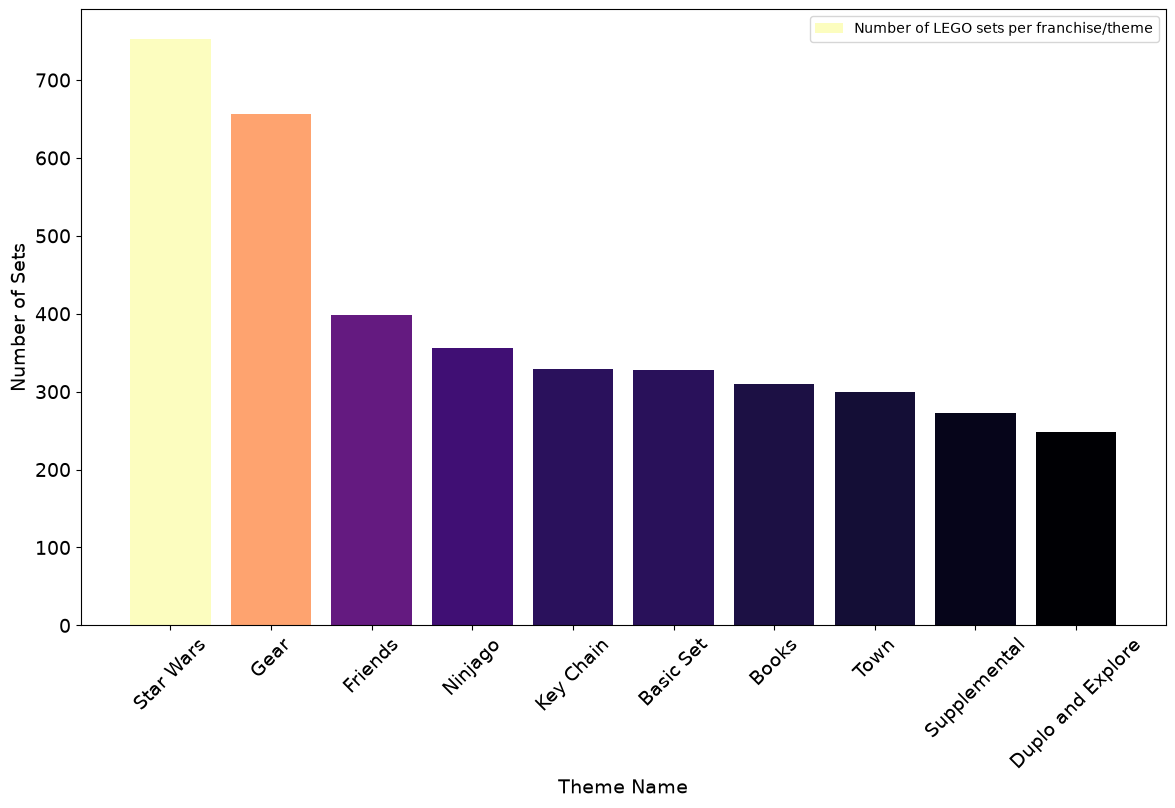

In [77]:
from matplotlib import colormaps
from matplotlib.colors import Normalize

top_10 = merged_df[:10]

norm = Normalize(
    vmin=top_10.set_count.min(),
    vmax=top_10.set_count.max()
)

colors = colormaps["magma"](norm(top_10.set_count))

plt.figure(figsize=(14, 8))

plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)

plt.ylabel("Number of Sets", fontsize=14)
plt.xlabel("Theme Name", fontsize=14)

plt.bar(
    top_10.name,
    top_10.set_count,
    color=colors,
    label="Number of LEGO sets per franchise/theme"
)

plt.legend()
plt.show()